<a href="https://colab.research.google.com/github/Ashutosh-Mi/GenAI_ML/blob/main/Ice_Cream_Sales_Prediction_using_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ice Cream Sales Prediction: A Linear Regression Approach

## README: Ice Cream Sales Prediction

This project analyzes the factors influencing ice cream sales and develops a predictive model based on temperature. The goal is to understand the relationship between environmental conditions and sales figures to inform business decisions.

### Dataset

The analysis uses the `ice-cream.csv` dataset, which includes the following features:
- `Date`: Date of the record
- `DayOfWeek`: Day of the week
- `Month`: Month of the year
- `Temperature`: Daily average temperature
- `Rainfall`: Daily rainfall amount
- `IceCreamsSold`: Number of ice creams sold

### Exploratory Data Analysis (EDA)

Key insights from the EDA include:
- **Strong Positive Correlation with Temperature**: A very strong linear relationship exists between `Temperature` and `IceCreamsSold` (correlation coefficient ~0.995).
- **Negligible Impact of Rainfall**: `Rainfall` shows a very weak correlation (-0.014) with sales, suggesting it's not a significant predictor in this dataset.
- **Seasonal Sales Pattern**: Sales are highest in summer months (July/August) and lowest in cooler months (April/October).
- **Minor Day-of-Week Variation**: While slight fluctuations exist, day of the week does not significantly impact overall sales compared to temperature.

### Predictive Modeling

A simple **Linear Regression model** was built to predict `IceCreamsSold` using `Temperature` as the sole predictor variable. The model was trained on 80% of the data and tested on the remaining 20%.

**Model Performance:**
- **R-squared**: Approximately 0.98, indicating that about 98% of the variance in ice cream sales can be explained by temperature.
- **Mean Squared Error**: Relatively low (around 44.70), suggesting good prediction accuracy.

**Model Coefficients:**
- `Intercept`: -235.11
- `Coefficient (Temperature)`: 5.02 (For every 1°F increase in temperature, approximately 5 more ice creams are sold).

### Business Recommendations

Based on the analysis, the following recommendations are made:
1.  **Seasonal Inventory Optimization**: Increase ice cream stock significantly during warmer months (May-August) and reduce it during cooler periods.
2.  **Targeted Marketing**: Intensify marketing campaigns during high-temperature periods to capitalize on increased demand.
3.  **Temperature-focused Forecasting**: Prioritize temperature as the most critical input for sales forecasting models.
4.  **Rainfall Consideration**: No major operational adjustments are needed based on rainfall, unless extreme weather conditions are anticipated.
5.  **Minor Promotions**: Consider small, targeted promotions on historically slower days to balance daily sales.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
data = pd.read_csv("/content/sample_data/ice-cream.csv")

In [4]:
data.head()

,Date,DayOfWeek,Month,Temperature,Rainfall,IceCreamsSold
0,2025-04-01,Tuesday,April,59.4,0.74,61
1,2025-04-03,Thursday,April,53.6,0.28,33
2,2025-04-06,Sunday,April,51.4,0.14,21
3,2025-04-07,Monday,April,50.8,0.06,23
4,2025-04-08,Tuesday,April,57.4,0.79,51


In [5]:
list(data.columns)

['Date', 'DayOfWeek', 'Month', 'Temperature', 'Rainfall', 'IceCreamsSold']

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           200 non-null    object 
 1   DayOfWeek      200 non-null    object 
 2   Month          200 non-null    object 
 3   Temperature    200 non-null    float64
 4   Rainfall       200 non-null    float64
 5   IceCreamsSold  200 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 9.5+ KB


In [7]:
data.describe()

,Temperature,Rainfall,IceCreamsSold
count,200.000000,200.000000,200.000000
mean,72.429500,0.283450,129.120000
std,11.602191,0.245561,58.234197
min,49.700000,0.000000,15.000000
25%,64.000000,0.110000,85.250000
50%,73.000000,0.205000,130.500000
75%,80.675000,0.387500,171.250000
max,98.300000,1.500000,256.000000


In [8]:
data.isnull().sum()

,0
Date,0
DayOfWeek,0
Month,0
Temperature,0
Rainfall,0
IceCreamsSold,0


In [9]:
[col for col in data.columns if data[col].dtype == 'object']

['Date', 'DayOfWeek', 'Month']

In [10]:
[col for col in data.columns if data[col].isnull().sum() > 0]

[]

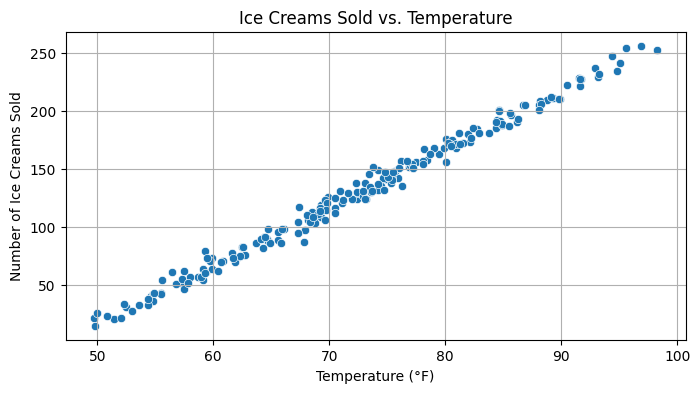

In [11]:
plt.figure(figsize=(8, 4))
sns.scatterplot(x='Temperature', y='IceCreamsSold', data=data)
plt.title('Ice Creams Sold vs. Temperature')
plt.xlabel('Temperature (°F)')
plt.ylabel('Number of Ice Creams Sold')
plt.grid(True)
plt.show()

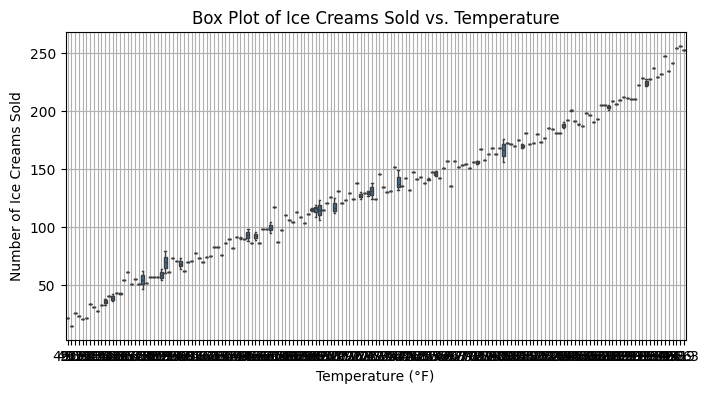

In [12]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Temperature', y='IceCreamsSold', data=data)
plt.title('Box Plot of Ice Creams Sold vs. Temperature')
plt.xlabel('Temperature (°F)')
plt.ylabel('Number of Ice Creams Sold')
plt.grid(True)
plt.show()

In [13]:
numerical_data=data.select_dtypes(include=[np.number])
categorical_data=data.select_dtypes(include=[object])
print(list(numerical_data.columns))
print(categorical_data.columns)

['Temperature', 'Rainfall', 'IceCreamsSold']
Index(['Date', 'DayOfWeek', 'Month'], dtype='object')


In [14]:
corr_matrix = numerical_data.corr()
corr_matrix

,Temperature,Rainfall,IceCreamsSold
Temperature,1.000000,0.024539,0.995541
Rainfall,0.024539,1.000000,-0.014479
IceCreamsSold,0.995541,-0.014479,1.000000


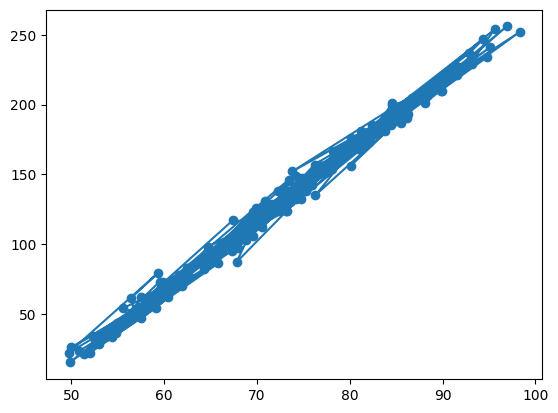

In [15]:
plt.plot(data['Temperature'], data['IceCreamsSold'], marker='o', linestyle='-')

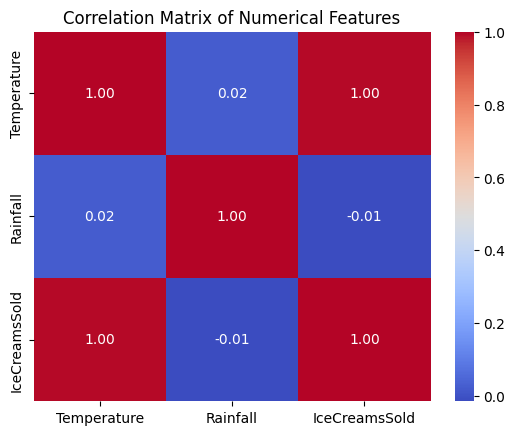

In [16]:
plt.plot(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

<Axes: xlabel='Temperature'>

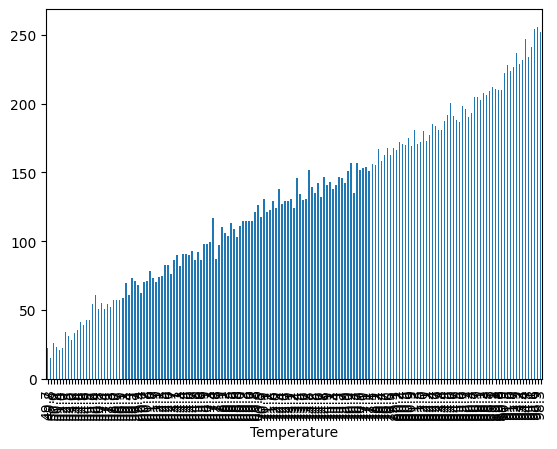

In [17]:
data.groupby('Temperature')['IceCreamsSold'].mean().plot(kind='bar')

In [21]:
monthsale=data.groupby('Month')['IceCreamsSold'].mean()

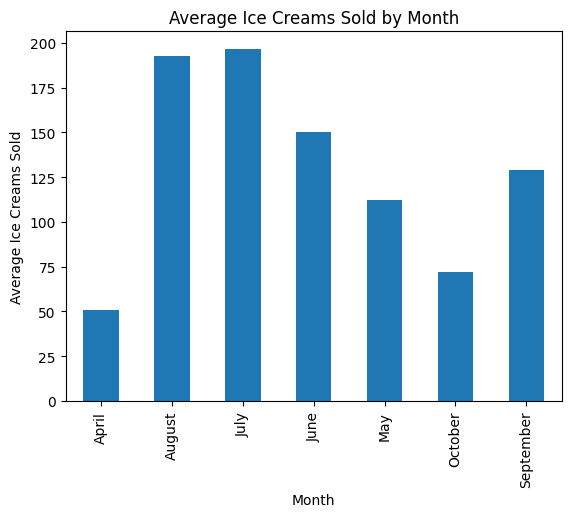

In [23]:
monthsale.plot(kind='bar')
plt.xlabel('Month')
plt.ylabel('Average Ice Creams Sold')
plt.title('Average Ice Creams Sold by Month')
plt.figsize=(8,6)
plt.show()

In [30]:
Daily=data.groupby('DayOfWeek')['IceCreamsSold'].mean()

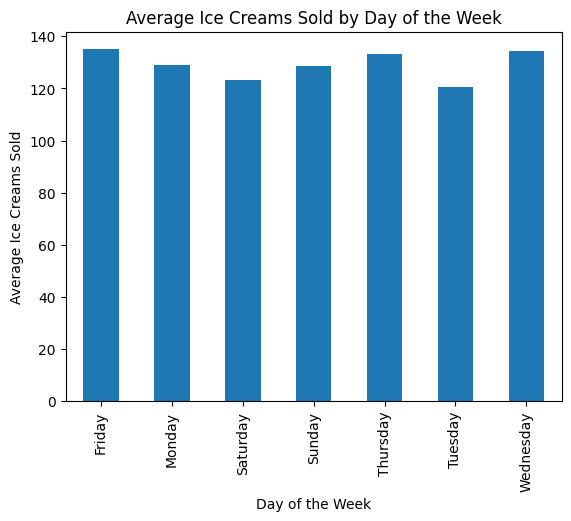

In [31]:
Daily.plot( kind='bar')
plt.xlabel('Day of the Week')
plt.ylabel('Average Ice Creams Sold')
plt.title('Average Ice Creams Sold by Day of the Week')
plt.show()

# inferences drawn


Based on the analysis we've done so far, here are some key inferences and potential business results:

Inferences:

1. Strong Positive Correlation between Temperature and Sales: The scatter plot and the correlation matrix (correlation coefficient of approximately 0.995) clearly show a very strong positive linear relationship between Temperature and IceCreamsSold. This means that as the temperature increases, ice cream sales significantly increase.
2. Negligible Impact of Rainfall: The Rainfall column shows a very weak correlation with IceCreamsSold (approximately -0.014), suggesting that rainfall, within the observed range, does not have a significant impact on ice cream sales.
3. Seasonal Sales Pattern: The bar plot of Average Ice Creams Sold by Month indicates a clear seasonal trend. Sales peak in the summer months (July and August) and are lowest in the cooler months (April and October). This aligns with general expectations for ice cream consumption.
4. Minor Day-of-Week Variation: The Average Ice Creams Sold by Day of the Week bar plot shows relatively consistent sales across the weekdays, with slightly higher sales on Fridays and Wednesdays/Thursdays, and slightly lower on Tuesdays. The weekend (Saturday/Sunday) sales are comparable to weekdays, suggesting that for this dataset, day of the week might not be as strong a driver as temperature or month.

### Business Results and Recommendations:

1. Optimize Inventory by Season: Since temperature is the primary driver and sales are highly seasonal, businesses should significantly increase ice cream stock during warmer months (May-August) and reduce it during cooler months (October-April) to minimize waste and maximize fresh product availability.
2. Targeted Marketing: Marketing efforts could be intensified in anticipation of and during peak temperature periods. Promotions related to hot weather or summer activities would likely be most effective.
3. Focus on Temperature-based Forecasting: Any sales forecasting model should heavily weigh temperature as its most critical input due to its overwhelming correlation with sales.
4. No Need to Over-Optimize for Rainfall: Given the weak correlation, there's likely no need to adjust operational strategies (like staffing or inventory) significantly based on predicted rainfall, unless extreme weather events (not covered by this data) are expected.
5. Consider Day-Specific Promotions: While not a massive swing, the slight dips on certain days (like Tuesday) could be opportunities for small, targeted promotions to even out daily sales.
Overall, the data strongly suggests that ice cream sales are primarily a function of temperature and, by extension, the time of year.

### Predicting Ice Cream Sales based on Temperature

Given the high correlation between temperature and ice cream sales, we can build a simple linear regression model to predict `IceCreamsSold` using `Temperature` as the predictor variable.

In [32]:
# Define features (X) and target (y)
X = data[['Temperature']]
y = data['IceCreamsSold']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape[0]} samples")
print(f"Testing data size: {X_test.shape[0]} samples")

Training data size: 160 samples
Testing data size: 40 samples


In [33]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

# Display model coefficients
print(f"\nModel Intercept: {model.intercept_:.2f}")
print(f"Model Coefficient (Temperature): {model.coef_[0]:.2f}")

Mean Squared Error: 44.70
R-squared: 0.98

Model Intercept: -235.11
Model Coefficient (Temperature): 5.02


The R-squared value close to 1 indicates that a large proportion of the variance in ice cream sales can be explained by temperature, which aligns with our earlier correlation findings.

Now, let's use the trained model to make a prediction for a new temperature value.

In [34]:
# Example prediction: Predict ice cream sales for a temperature of 75°F
new_temperature = np.array([[75]])
predicted_sales = model.predict(new_temperature)

print(f"Predicted Ice Creams Sold for 75°F: {predicted_sales[0]:.0f}")

Predicted Ice Creams Sold for 75°F: 142


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Improvement

In [35]:
new_temperatures_multiple_samples = np.array([[60], [75], [90]])
# This array has shape (3, 1), meaning 3 samples, 1 feature each.

predicted_sales_multiple = model.predict(new_temperatures_multiple_samples)
print(f"Predicted sales for multiple temperatures: {predicted_sales_multiple.round(0)}")

Predicted sales for multiple temperatures: [ 66. 142. 217.]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [36]:
# Assuming a model trained on ['Temperature', 'Rainfall']
# Each inner list represents one sample, with two features.
new_data_multiple_features = np.array([
    [70, 0.1],  # Sample 1: Temp=70, Rainfall=0.1
    [85, 0.5]   # Sample 2: Temp=85, Rainfall=0.5
])
# This array has shape (2, 2), meaning 2 samples, 2 features each.

# predicted_sales_multi_features = model_with_two_features.predict(new_data_multiple_features)
# print(f"Predicted sales: {predicted_sales_multi_features}")

Key Takeaway: The predict() method (and many other scikit-learn methods) expects input in a (n_samples, n_features) shape. Even when n_samples or n_features is 1, you still need to maintain this 2D structure.